In [1]:
# Array and data functions
from glob import glob
import numpy as np
import pandas as pd

# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler, ConfIntSampler

import warnings
warnings.filterwarnings('ignore')

In [2]:
BasePath ='/Volumes/evocell/Microscopy/Octavio/Strains/Megaterium_ponA_inductions/20250929/processed_masks/' 

images = sorted(glob(BasePath+'*.tif'))

strains = np.unique([img.split('/')[-1].split('_')[0] for img in images])

print(strains)

print(f'Total images: {len(images)}')

['JLG1561' 'JLG6822' 'JLG6872']
Total images: 100


In [3]:
dfs = []

for s in strains:

    images = sorted(glob(f'{BasePath}{s}*.tif'))

    iptg = np.unique([img.split('/')[-1].split('_')[1] for img in images])

    for i in iptg:

        masks = sorted(glob(f'{BasePath}{s}_{i}_*.tif'))
        df = SizeDataFrame(masks)
        
        df.insert(0,'Strain',s)
        df.insert(1,'IPTG',i)

        dfs.append(df)

dfs = pd.concat(dfs,ignore_index=True)
dfs = dfs[dfs['Width'] > 0.3]

In [4]:
metrics = ['Length','Width','SurfaceArea','Volume']
columns = ['Strain','IPTG']
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Figures/FigureS4/posterior_segmentation_measurements.csv')

final_df = ParamSampler(dfs,df_posteriors,columns,metrics)

In [5]:
w = ConfIntSampler(final_df,columns=['Strain','IPTG'],metric='Width_mu',interval=0.99)
L = ConfIntSampler(final_df,columns=['Strain','IPTG'],metric='Length_mu',interval=0.99)



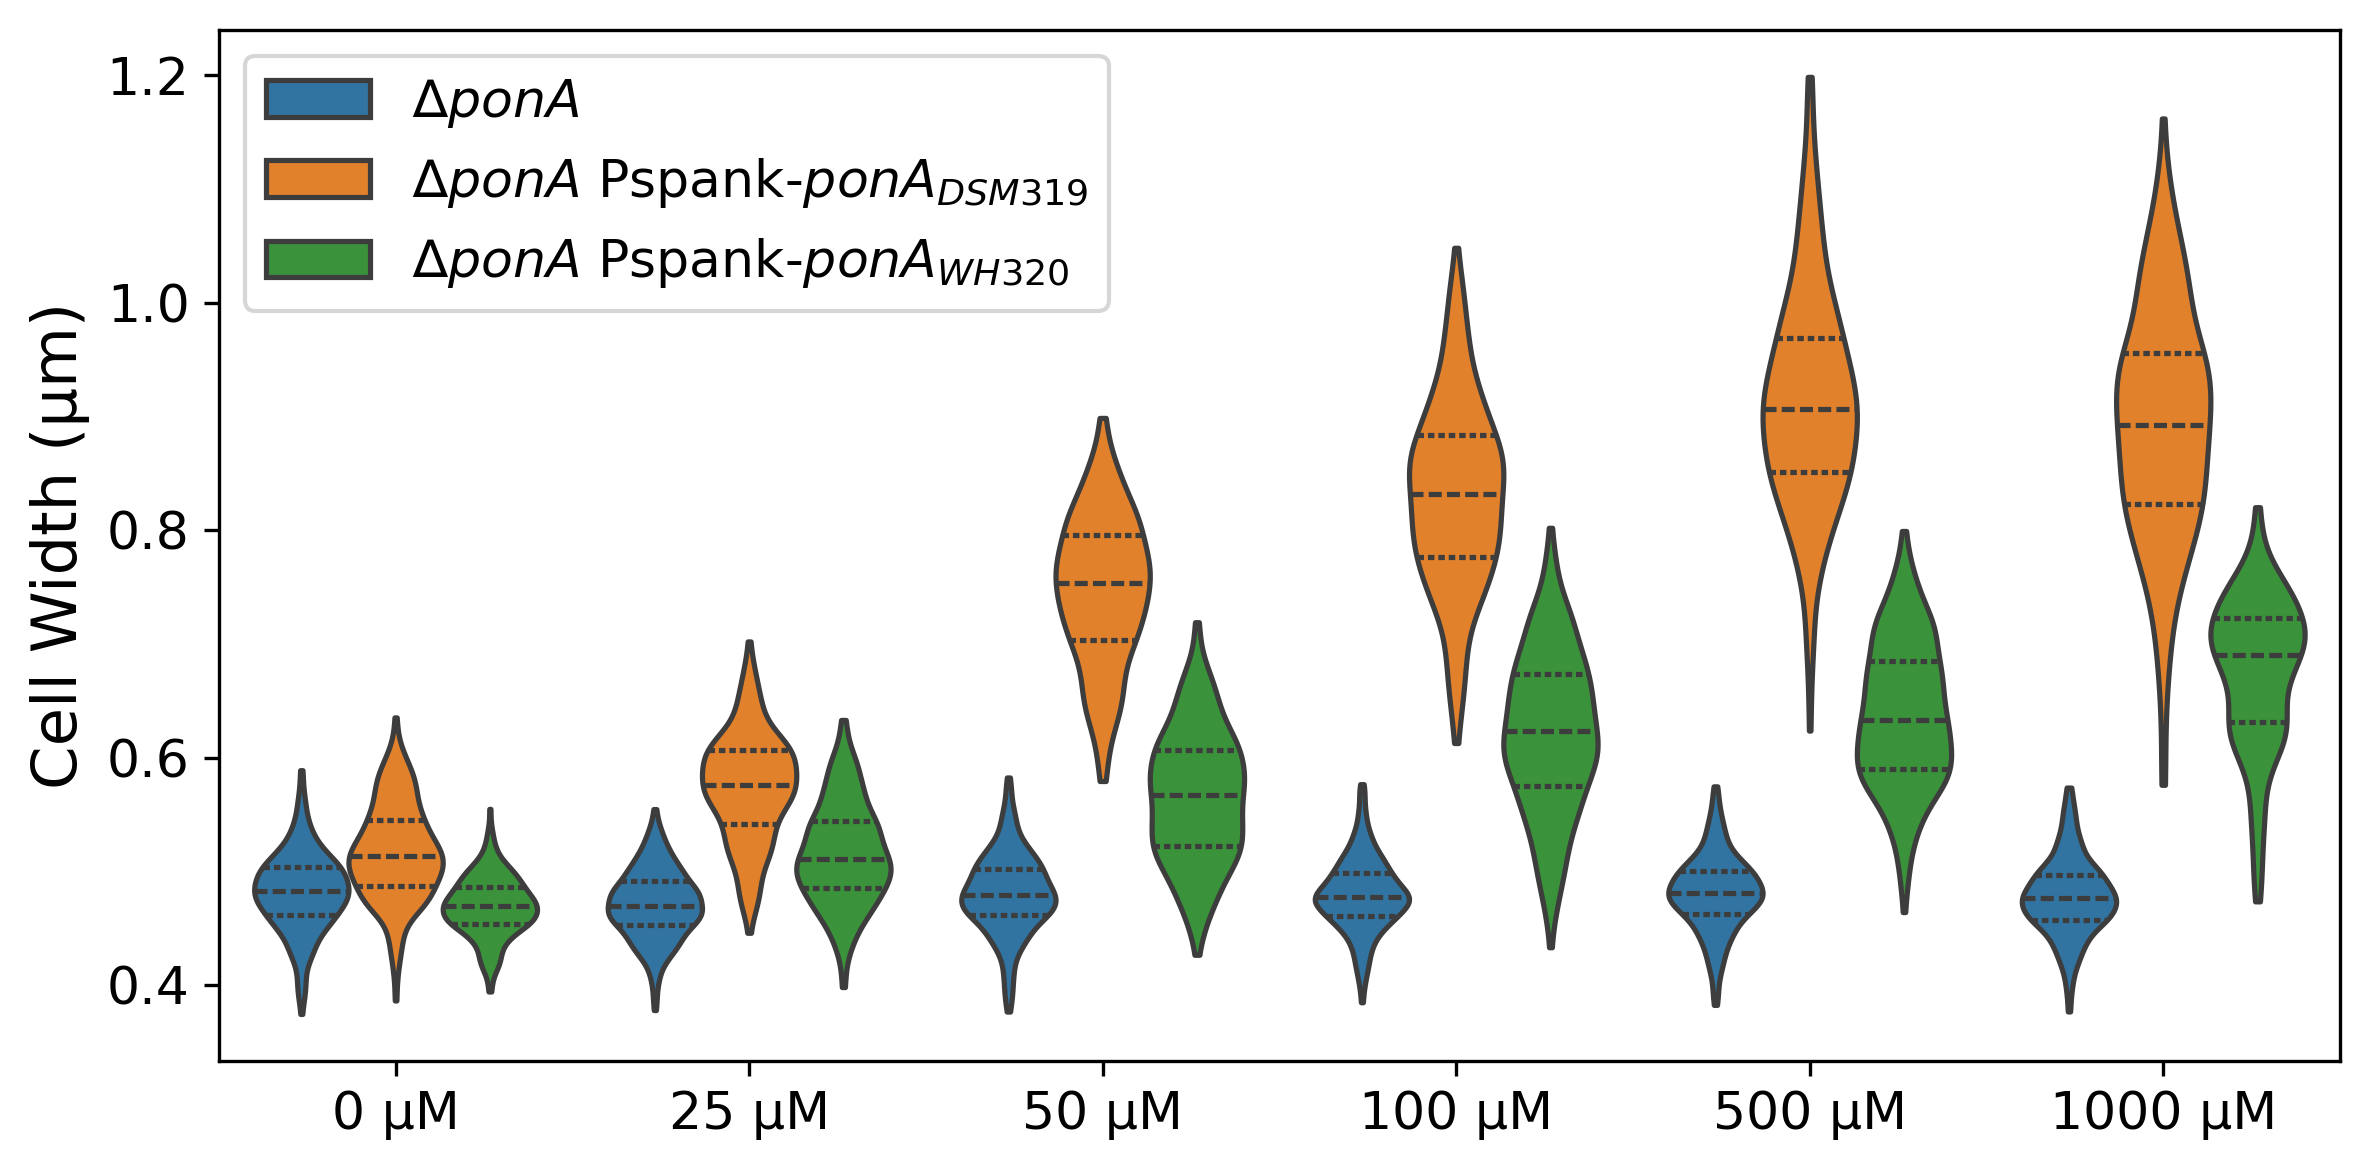

In [6]:
fig,ax = plt.subplots(dpi=300,figsize=(8,4))

strain_order = ['JLG1561','JLG6872','JLG6822']

labels = ['∆$ponA$','∆$ponA$ Pspank-$ponA_{DSM319}$','∆$ponA$ Pspank-$ponA_{WH320}$']

xticklabs = [0,25,50,100,500,1000]
xticklabs2 = [f'{x} µM' for x in xticklabs]

sns.violinplot(x=w['IPTG'],y=w['Width_mu'],order=['0uM','25uM','50uM','100uM','500uM','1000uM'],hue=w['Strain'],ax=ax,hue_order=strain_order,inner='quart',scale='width',cut=0)
ax.set_xticklabels(xticklabs2,fontsize=12.5)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5)
ax.set_xlabel('')
ax.set_ylabel('Cell Width (µm)',fontsize=15)
ax.legend(title=None,labels=labels,handles=ax.get_legend_handles_labels()[0],fontsize=12.5)

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/Imaging_paper/Fig6_new/ponA_inductions_width.png')

In [10]:
w.groupby(['IPTG','Strain']).size().reset_index(name='counts')

,IPTG,Strain,counts
0,0uM,JLG1561,492
1,0uM,JLG6822,263
2,0uM,JLG6872,518
3,1000uM,JLG1561,607
4,1000uM,JLG6822,404
5,1000uM,JLG6872,319
6,100uM,JLG1561,827
7,100uM,JLG6822,517
8,100uM,JLG6872,626
9,25uM,JLG1561,484
